In [1]:
!lscpu

import psutil

print("CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPUs:", psutil.cpu_count(logical=True))
print("Memory (GB):", round(psutil.virtual_memory().total / 1e9, 2))
print("Disk space (GB):", round(psutil.disk_usage('/').total / 1e9, 2))

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4399.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

Nonlinear MLP backbone experiment  (seed=111, 5000 epochs)

 Scale |     SNR |  Model |  SigR²Tr |  SigR²Te |  NoisR²Te | Time
------------------------------------------------------------------
   0.0 |    92.4 |    VAE |    0.909 |    0.871 |     1.000 | 52s
   0.0 |    92.4 |     AR |    0.999 |    0.999 |     1.000 | 36s
   0.0 |    92.4 |   JEPA |    0.994 |    0.993 |     1.000 | 41s
   0.0 |    92.4 |  VJEPA |    0.996 |    0.996 |     1.000 | 56s
   0.0 |    92.4 |  BJEPA |    0.991 |    0.990 |     1.000 | 61s
------------------------------------------------------------------
   1.0 |    15.8 |    VAE |    0.922 |    0.911 |    -0.040 | 43s
   1.0 |    15.8 |     AR |    0.968 |    0.970 |    -0.020 | 34s
   1.0 |    15.8 |   JEPA |    0.994 |    0.993 |    -0.009 | 40s
   1.0 |    15.8 |  VJEPA |    0.989 |    0.990 |    -0.017 | 53s
   1.0 |    15.8 |  BJEPA |    0.971 |    0.967 |     0.003 | 62s
------------------------------------------------------------------
   2.0 |    

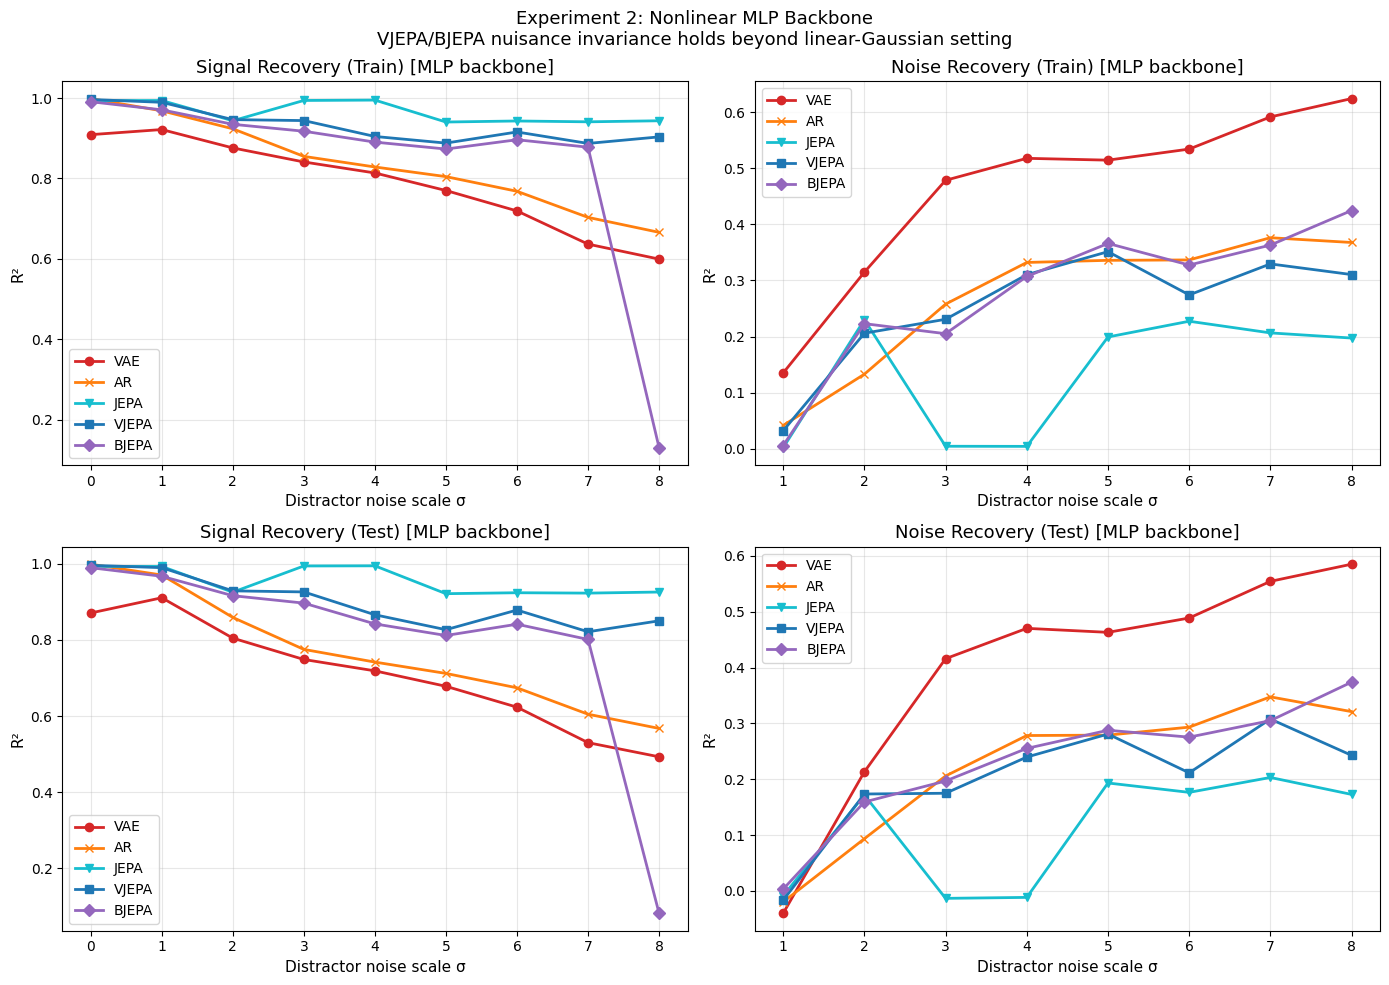

Saved: fig_nonlinear_results.pdf


In [2]:
"""
Experiment 2: Nonlinear MLP Backbone
=====================================
Addresses:
  - Reviewer ZQ8k W1: "linear-Gaussian VJEPA may trivially collapse to PCA;
    it remains uncertain whether the method would be effective in a more complex
    non-linear or non-Gaussian setting."
  - Promised in rebuttal: "we will add nonlinear experiments with learned MLP
    encoder/predictor modules."

What this script does:
  Replaces every nn.Linear backbone with a 2-layer MLP (Linear → Tanh → Linear),
  keeping the identical experiment setup, loss functions, and evaluation protocol.
  This demonstrates that VJEPA's nuisance-invariance property holds beyond
  the linear-Gaussian special case.

Produces:
  - fig_nonlinear_results.pdf  (2×2 signal/noise recovery grid, same style as Fig. 4)
  - Console table comparable to Table 4 of the paper

Runtime estimate: ~20 min on Colab CPU (3 scales × 5 models × 5000 epochs)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy
import time

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEED     = 111
SCALES   = np.linspace(0, 8.0, 9)
N_TRAIN  = 6000
N_TEST   = 2000
N_EPOCHS = 5000
LR       = 1e-3
BETA     = 0.01
GAMMA    = 0.10
EMA_TAU  = 0.99
DIM_S    = 4
DIM_D    = 4
DIM_X    = 20
DIM_Z    = 4
HIDDEN   = 32          # MLP hidden width

torch.manual_seed(SEED); np.random.seed(SEED)

# ── Environment (identical to paper) ──────────────────────────────────────────
class DistractorSystem:
    def __init__(self):
        H = np.random.randn(DIM_S, DIM_S)
        Q, _ = np.linalg.qr(H)
        self.A   = torch.FloatTensor(Q)
        self.A_d = 0.9 * torch.eye(DIM_D)
        C = np.random.randn(DIM_X, DIM_S); C /= np.linalg.norm(C, axis=0, keepdims=True)
        D = np.random.randn(DIM_X, DIM_D); D /= np.linalg.norm(D, axis=0, keepdims=True)
        self.C = torch.FloatTensor(C)
        self.D = torch.FloatTensor(D)

    def generate(self, n):
        s = torch.zeros(n+1, DIM_S); s[0] = torch.randn(DIM_S)
        d = torch.zeros(n+1, DIM_D); d[0] = torch.randn(DIM_D)
        for t in range(n):
            s[t+1] = s[t] @ self.A.T + torch.randn(DIM_S) * 0.1
            d[t+1] = d[t] @ self.A_d.T + torch.randn(DIM_D) * 0.3
        return s, d

    def observe(self, s, d_base, scale):
        n = s.shape[0] - 1
        d = d_base * scale
        x = s @ self.C.T + d @ self.D.T + torch.randn(n+1, DIM_X) * 0.01
        return x[:-1], x[1:], s[:-1], s[1:], d[:-1], d[1:]


# ── MLP building block ─────────────────────────────────────────────────────────
def mlp(in_dim, out_dim, hidden=HIDDEN):
    """Two-layer MLP with Tanh nonlinearity."""
    return nn.Sequential(
        nn.Linear(in_dim, hidden, bias=True),
        nn.Tanh(),
        nn.Linear(hidden, out_dim, bias=True)
    )


# ── Models (MLP backbones) ─────────────────────────────────────────────────────
class MLPVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_mu     = mlp(DIM_X, DIM_Z)
        self.enc_logvar = mlp(DIM_X, DIM_Z)
        self.dec        = mlp(DIM_Z, DIM_X)

    def forward(self, x):
        mu, lv = self.enc_mu(x), self.enc_logvar(x)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)
        return self.dec(z), mu, lv

    def latent(self, x, _=None): return self.enc_mu(x)


class MLPAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = mlp(DIM_X, DIM_Z)
        self.pred = mlp(DIM_Z, DIM_X)

    def forward(self, x): return self.pred(self.enc(x)), self.enc(x)
    def latent(self, x, _=None): return self.enc(x)


class MLPJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = mlp(DIM_X, DIM_Z)
        self.pred = mlp(DIM_Z, DIM_Z)
        self.tgt  = deepcopy(self.enc)
        for p in self.tgt.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zp = self.pred(self.enc(xt))
        with torch.no_grad(): zt = self.tgt(xn)
        return zp, zt

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None): return self.pred(self.enc(x))


class MLPVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = mlp(DIM_X, DIM_Z)
        self.pred_mu     = mlp(DIM_Z, DIM_Z)
        self.pred_logvar = mlp(DIM_Z, DIM_Z)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = mlp(DIM_X, DIM_Z)
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        p_mu, p_lv = self.pred_mu(zt), self.pred_logvar(zt)
        with torch.no_grad():
            t_mu, t_lv = self.tgt_mu(xn), self.tgt_logvar(xn)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (p_mu, p_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None): return self.pred_mu(self.enc(x))


class MLPBJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = mlp(DIM_X, DIM_Z)
        self.pred_mu     = mlp(DIM_Z, DIM_Z)
        self.pred_logvar = mlp(DIM_Z, DIM_Z)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = mlp(DIM_X, DIM_Z)
        self.prior_mu    = nn.Parameter(torch.zeros(DIM_Z))
        self.prior_lv    = nn.Parameter(torch.zeros(DIM_Z))
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    @staticmethod
    def poe(mu1, lv1, mu2, lv2):
        pr1, pr2 = (-lv1).exp(), (-lv2).exp()
        pr = pr1 + pr2
        return (mu1*pr1 + mu2*pr2) / pr, -pr.log()

    def forward(self, xt, xn):
        zt = self.enc(xt)
        d_mu, d_lv = self.pred_mu(zt), self.pred_logvar(zt)
        B = xt.size(0)
        pr_mu = self.prior_mu.unsqueeze(0).expand(B, -1)
        pr_lv = self.prior_lv.unsqueeze(0).expand(B, -1)
        with torch.no_grad():
            t_mu, t_lv = self.tgt_mu(xn), self.tgt_logvar(xn)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (d_mu, d_lv), (pr_mu, pr_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x, _=None):
        zt = self.enc(x)
        d_mu, d_lv = self.pred_mu(zt), self.pred_logvar(zt)
        B = x.size(0)
        pr_mu = self.prior_mu.unsqueeze(0).expand(B, -1)
        pr_lv = self.prior_lv.unsqueeze(0).expand(B, -1)
        mu, _ = self.poe(d_mu, d_lv, pr_mu, pr_lv)
        return mu


# ── Losses (identical to paper) ────────────────────────────────────────────────
def vicreg(x, y, sim=25., std=25., cov=1.):
    loss = sim * nn.functional.mse_loss(x, y)
    loss += std * (torch.relu(1-(x.var(0)+1e-4).sqrt()).mean() +
                   torch.relu(1-(y.var(0)+1e-4).sqrt()).mean())
    x, y = x - x.mean(0), y - y.mean(0)
    N, D = x.shape
    cx = x.T @ x / (N-1)
    loss += cov * (cx.pow(2).sum() - cx.diag().pow(2).sum()) / D
    return loss

def vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv):
    pv  = p_lv.exp()
    nll = 0.5 * (pv.log() + (z_s-p_mu).pow(2)/pv).sum(-1).mean()
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA * kl

def bjepa_loss(z_s, d_mu, d_lv, pr_mu, pr_lv, t_mu, t_lv):
    base = vjepa_loss(z_s, d_mu, d_lv, t_mu, t_lv)
    vr = (d_lv - pr_lv).exp()
    kl_pr = 0.5 * (vr + (pr_mu-d_mu).pow(2)/pr_lv.exp() - 1 - (d_lv-pr_lv)).sum(-1).mean()
    return base + GAMMA * kl_pr


# ── Train + Eval ───────────────────────────────────────────────────────────────
MODELS = {
    'VAE':   MLPVAE,
    'AR':    MLPAR,
    'JEPA':  MLPJEPA,
    'VJEPA': MLPVJEPA,
    'BJEPA': MLPBJEPA,
}

def train(mdl, name, xt, xn):
    opt = optim.Adam(mdl.parameters(), lr=LR)
    for _ in range(N_EPOCHS):
        opt.zero_grad()
        if name == 'VAE':
            xh, mu, lv = mdl(xt)
            loss = nn.functional.mse_loss(xh, xt, reduction='sum') \
                   - 0.5*(1+lv-mu.pow(2)-lv.exp()).sum()
        elif name == 'AR':
            loss = nn.functional.mse_loss(mdl(xt)[0], xn)
        elif name == 'JEPA':
            zp, zt = mdl(xt, xn); loss = vicreg(zp, zt); mdl.ema()
        elif name == 'VJEPA':
            z_s, (pm, pl), (tm, tl) = mdl(xt, xn)
            loss = vjepa_loss(z_s, pm, pl, tm, tl); mdl.ema()
        elif name == 'BJEPA':
            z_s, (dm, dl), (prm, prl), (tm, tl) = mdl(xt, xn)
            loss = bjepa_loss(z_s, dm, dl, prm, prl, tm, tl); mdl.ema()
        loss.backward(); opt.step()


def eval_r2(mdl, name, xt_n, xt_e_n, y_tr, y_te):
    with torch.no_grad():
        z_tr = mdl.latent(xt_n).numpy()
        z_te = mdl.latent(xt_e_n).numpy()
    reg = LinearRegression().fit(z_tr, y_tr.numpy())
    return (r2_score(y_tr.numpy(), reg.predict(z_tr)),
            r2_score(y_te.numpy(), reg.predict(z_te)))


# ── Main Experiment ────────────────────────────────────────────────────────────
def run():
    env = DistractorSystem()
    s_tr, d_tr = env.generate(N_TRAIN)
    s_te, d_te = env.generate(N_TEST)

    results = {m: {'sig_tr':[], 'sig_te':[], 'noi_tr':[], 'noi_te':[]} for m in MODELS}

    hdr = f"{'Scale':>6} | {'SNR':>7} | {'Model':>6} | {'SigR²Tr':>8} | {'SigR²Te':>8} | {'NoisR²Te':>9} | Time"
    print(hdr); print("-"*len(hdr))

    for scale in SCALES:
        xt, xn, st, sn, dt, dn = env.observe(s_tr, d_tr, scale)
        xe, xne, se, sne, de, dne = env.observe(s_te, d_te, scale)
        mu_n, std_n = xt.mean(0), xt.std(0)+1e-6
        xt_n, xn_n   = (xt-mu_n)/std_n, (xn-mu_n)/std_n
        xe_n, xne_n  = (xe-mu_n)/std_n, (xne-mu_n)/std_n
        snr = 10 * np.log10(st.pow(2).mean().item() / (dt.pow(2).mean().item()+1e-8))

        for name, Cls in MODELS.items():
            t0 = time.time()
            mdl = Cls()
            train(mdl, name, xt_n, xn_n)

            if name == 'VAE':
                rs_tr, rs_te = eval_r2(mdl, name, xt_n, xe_n, st, se)
                rn_tr, rn_te = eval_r2(mdl, name, xt_n, xe_n, dt, de)
            else:
                rs_tr, rs_te = eval_r2(mdl, name, xt_n, xe_n, sn, sne)
                rn_tr, rn_te = eval_r2(mdl, name, xt_n, xe_n, dn, dne)

            results[name]['sig_tr'].append(rs_tr); results[name]['sig_te'].append(rs_te)
            results[name]['noi_tr'].append(rn_tr); results[name]['noi_te'].append(rn_te)
            elapsed = time.time() - t0
            print(f"{scale:>6.1f} | {snr:>7.1f} | {name:>6} | "
                  f"{rs_tr:>8.3f} | {rs_te:>8.3f} | {rn_te:>9.3f} | {elapsed:.0f}s")

        print("-"*len(hdr))

    return results


def plot_results(results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = {'VAE':'#d62728','AR':'#ff7f0e','JEPA':'#17becf','VJEPA':'#1f77b4','BJEPA':'#9467bd'}
    markers = {'VAE':'o','AR':'x','JEPA':'v','VJEPA':'s','BJEPA':'D'}

    titles = [('Signal Recovery (Train)', 'sig_tr', False),
              ('Noise Recovery (Train)',   'noi_tr', True),
              ('Signal Recovery (Test)',   'sig_te', False),
              ('Noise Recovery (Test)',    'noi_te', True)]

    for ax, (title, key, skip_zero) in zip(axes.flat, titles):
        xs = SCALES[1:] if skip_zero else SCALES
        for name in MODELS:
            ys = results[name][key][1:] if skip_zero else results[name][key]
            ax.plot(xs, ys, label=name, color=colors[name], marker=markers[name], linewidth=2)
        ax.set_title(title + ' [MLP backbone]', fontsize=13)
        ax.set_xlabel('Distractor noise scale σ', fontsize=11)
        ax.set_ylabel('R²', fontsize=11)
        ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.suptitle('Experiment 2: Nonlinear MLP Backbone\n'
                 'VJEPA/BJEPA nuisance invariance holds beyond linear-Gaussian setting',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_nonlinear_results.pdf', bbox_inches='tight')
    plt.show()
    print("Saved: fig_nonlinear_results.pdf")


if __name__ == '__main__':
    print(f"Nonlinear MLP backbone experiment  (seed={SEED}, {N_EPOCHS} epochs)\n")
    results = run()
    plot_results(results)